In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import matplotlib.pyplot as plt


C:\Users\Kaustubh Gupta\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Test data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r'C:\Users\Kaustubh Gupta\Downloads\test\PetImages',
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    r'C:\Users\Kaustubh Gupta\Downloads\Train\animals',
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)


Found 25000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [3]:
cnn = Sequential()

# Convolution Block 1
cnn.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
cnn.add(MaxPooling2D(pool_size=(2,2)))

# Block 2
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))

# Block 3
cnn.add(Conv2D(128,(3,3),activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
cnn.add(Flatten())

# Fully connected layer
cnn.add(Dense(128, activation='relu'))

# Output layer
cnn.add(Dense(1, activation='sigmoid'))

cnn.summary()


C:\Users\Kaustubh Gupta\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [5]:
history = cnn.fit(
    train_generator,
    steps_per_epoch=10,
    epochs=10,
    validation_data=test_generator,
    validation_steps=50
)

Epoch 1/10


C:\Users\Kaustubh Gupta\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 48s 5s/step - accuracy: 0.4112 - loss: 0.7158 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 2/10
 2/10 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4297 - loss: 0.6947

C:\Users\Kaustubh Gupta\anaconda3\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4924 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6963
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5055 - loss: 0.6950 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4578 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4311 - loss: 0.6976 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5071 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4779 - loss: 0.6944 - val_accuracy: 0.6940 - val_loss: 0.6925
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5619 - loss: 0.6925 - val_accuracy: 0.5790 - val_loss: 0.6913
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4937 - loss: 0.6933 - val_accuracy: 0.7020 - val_loss: 0.6904
Epo

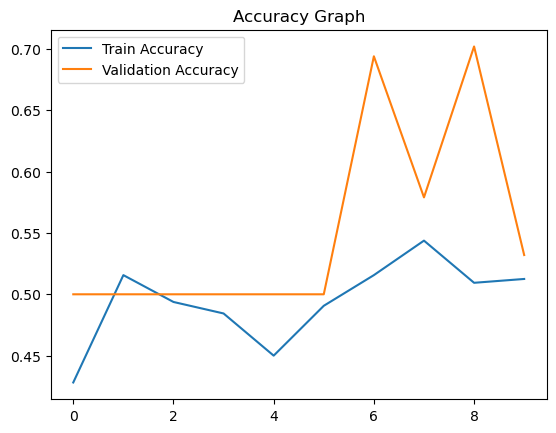

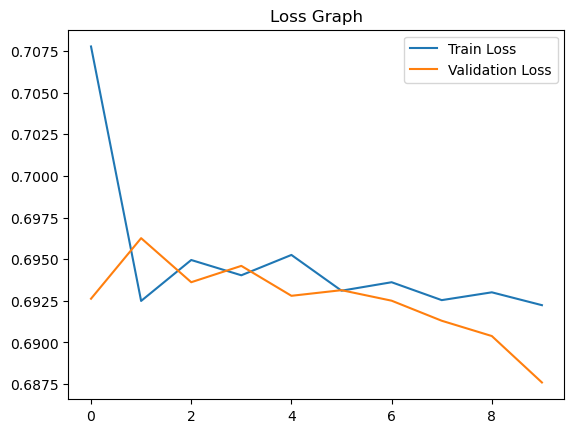

In [10]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()


In [14]:
img_path = r"C:\Users\Kaustubh Gupta\Downloads\test\PetImages\Cat\998.jpg"  

img = image.load_img(img_path, target_size=(64,64))
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)

result = cnn.predict(img)

print(result)

if result[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[0.04784593]]
Cat


In [15]:
img_path = r"C:\Users\Kaustubh Gupta\Downloads\test\PetImages\Dog\9989.jpg"

img = image.load_img(img_path, target_size=(64,64))
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)

result = cnn.predict(img)

print(result)

if result[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.9595521]]
Dog
